In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
import shap
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load processed dataset

In [41]:
df_training = pd.read_csv('FIFA_Binary_Cleaned_Final_Train.csv')
df_testing = pd.read_csv('FIFA_Binary_Cleaned_Final_Test.csv')

In [43]:
df_training.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_testing.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [53]:
target_col = 'overall_binary'

q1, q2 = df_training[target_col].quantile([0.33, 0.66])

def make_3_classes(x):
    if x <= q1: return 0    # Low
    elif x <= q2: return 1  # Medium
    else: return 2          # High

y_train = df_training[target_col].apply(make_3_classes)
y_test = df_testing[target_col].apply(make_3_classes)

In [45]:
cols_to_drop = ['overall', 'overall_binary'] 
X_train = df_training.drop(columns=cols_to_drop, errors='ignore')
X_test = df_testing.drop(columns=cols_to_drop, errors='ignore')

# Anomaly Detection methods

In [46]:
pca = PCA(n_components=2)
df_reduced = pd.DataFrame(pca.fit_transform(X_train), columns=['PC1', 'PC2'])

In [47]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso_anoms = (iso.fit_predict(X_train_pca) == -1)

In [48]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_train_pca)
dist, _ = knn.kneighbors(X_train_pca)
knn_thresh = np.percentile(dist[:, -1], 90)
knn_anoms = dist[:, -1] > knn_thresh

In [49]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof_anoms = (lof.fit_predict(X_train_pca) == -1)

In [50]:
anomalies = iso_anoms.astype(int) + knn_anoms.astype(int) + lof_anoms.astype(int)

# Visualising anomalies

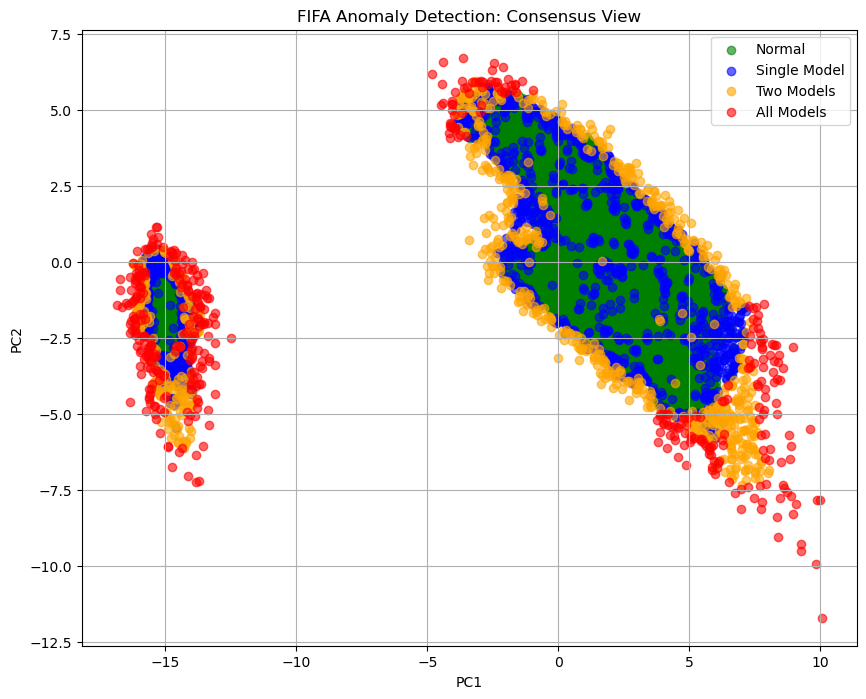

In [51]:
plt.figure(figsize=(10, 8))
colors = {0: 'green', 1: 'blue', 2: 'orange', 3: 'red'}
labels = {0: 'Normal', 1: 'Single Model', 2: 'Two Models', 3: 'All Models'}

for val in np.unique(anomalies):
    mask_plot = (anomalies == val)
    plt.scatter(df_reduced.loc[mask_plot, 'PC1'], df_reduced.loc[mask_plot, 'PC2'], 
                color=colors[val], label=labels[val], alpha=0.6)

plt.title('FIFA Anomaly Detection: Consensus View')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
mask_refined = anomalies < 2
X_train_refined = X_train[mask_refined].reset_index(drop=True)
y_train_refined = y_train[mask_refined].reset_index(drop=True)

print(f"Original: {X_train.shape[0]} | Refined: {X_train_refined.shape[0]}")

Original: 14622 | Refined: 13395


In [57]:
X_train_iter = X_train_refined.copy() 
X_test_iter = X_test.copy()
remaining_features = X_train_iter.columns.tolist()

# Recursive Feature Elimination (RFE)

In [55]:
remaining_features = X_train_refined.columns.tolist()
best_accuracy = 0
best_features = []

while len(remaining_features) > 1:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
        n_estimators=50, random_state=42
    )
    model.fit(X_train_refined[remaining_features], y_train_refined)
    
    y_pred = model.predict(X_test[remaining_features])
    acc = accuracy_score(y_test, y_pred)
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_features = remaining_features.copy()
        best_model = model

    importances = model.feature_importances_
    least_imp = remaining_features[np.argmin(importances)]
    remaining_features.remove(least_imp)
    print(f"Feats: {len(remaining_features)+1} | Current Acc: {acc:.4f} | Removed: {least_imp}")

print(f"\nFinal Best Accuracy: {best_accuracy:.4f}")
print(f"Optimal Feature Count: {len(best_features)}")

Feats: 73 | Current Acc: 0.9789 | Removed: num_positions
Feats: 72 | Current Acc: 0.9789 | Removed: international_reputation
Feats: 71 | Current Acc: 0.9784 | Removed: nation_position
Feats: 70 | Current Acc: 0.9770 | Removed: player_tags_count
Feats: 69 | Current Acc: 0.9819 | Removed: gk_kicking
Feats: 68 | Current Acc: 0.9781 | Removed: skill_moves
Feats: 67 | Current Acc: 0.9789 | Removed: gk_speed
Feats: 66 | Current Acc: 0.9776 | Removed: nation_jersey_number
Feats: 65 | Current Acc: 0.9773 | Removed: gk_diving
Feats: 64 | Current Acc: 0.9773 | Removed: real_face_Yes
Feats: 63 | Current Acc: 0.9778 | Removed: preferred_foot_Right
Feats: 62 | Current Acc: 0.9778 | Removed: gk_handling
Feats: 61 | Current Acc: 0.9773 | Removed: weak_foot
Feats: 60 | Current Acc: 0.9768 | Removed: gk_positioning
Feats: 59 | Current Acc: 0.9795 | Removed: gk_reflexes
Feats: 58 | Current Acc: 0.9787 | Removed: body_type
Feats: 57 | Current Acc: 0.9806 | Removed: dribbling
Feats: 56 | Current Acc: 0.97

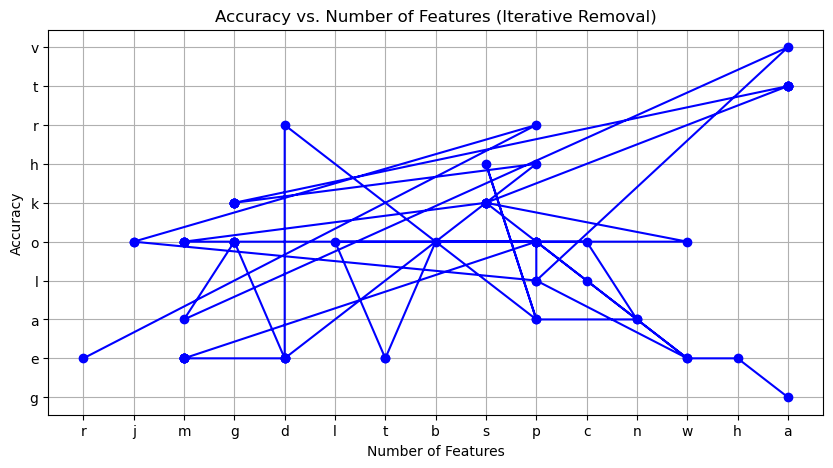

In [59]:
plt.figure(figsize=(10, 5))
plt.plot([h[0] for h in best_features], [h[1] for h in best_features], marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Number of Features (Iterative Removal)')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.gca().invert_xaxis()  
plt.grid(True)
plt.show()

# Corrolation matrix


--- Final Classification Report ---
              precision    recall  f1-score   support

         Low       0.98      0.99      0.98      1749
      Medium       0.99      0.98      0.98      1907
        High       0.00      0.00      0.00         0

    accuracy                           0.98      3656
   macro avg       0.65      0.65      0.65      3656
weighted avg       0.98      0.98      0.98      3656



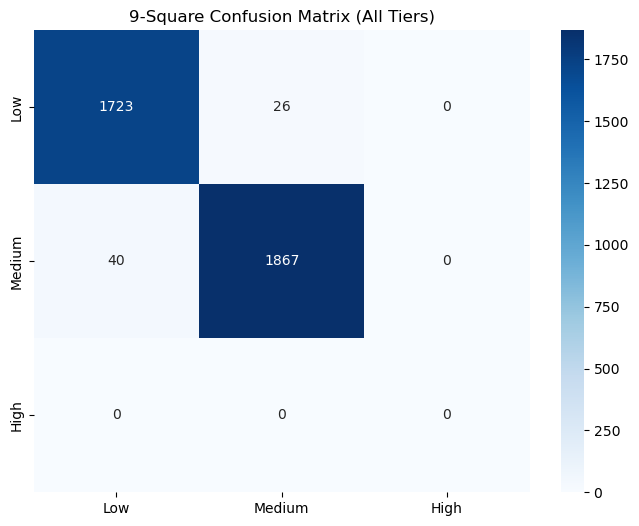

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

unique_classes = np.unique(y_test)
target_names = ['Low', 'Medium', 'High']

print("\n--- Final Classification Report ---")
print(classification_report(
    y_test, 
    final_preds, 
    labels=[0, 1, 2], 
    target_names=['Low', 'Medium', 'High'],
    zero_division=0  
))

cm = confusion_matrix(y_test, final_preds, labels=[0, 1, 2])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title("9-Square Confusion Matrix (All Tiers)")
plt.show()

Classes found in training: [0 1]


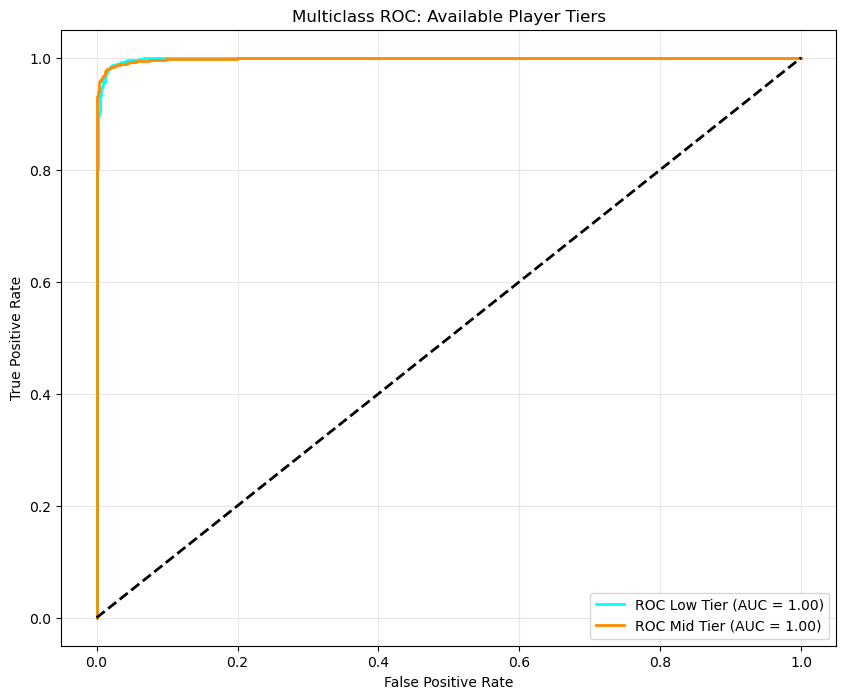

In [66]:
import numpy as np
from sklearn.metrics import roc_curve, auc

existing_classes = np.unique(y_train_refined)
print(f"Classes found in training: {existing_classes}")

ovr_model = OneVsRestClassifier(best_model)
ovr_model.fit(X_train_refined[best_features], y_train_refined)
y_score = ovr_model.predict_proba(X_test[best_features])

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
class_labels = {0: 'Low Tier', 1: 'Mid Tier', 2: 'High Tier'}

for i in range(y_score.shape[1]):
    
    actual_class_id = existing_classes[i]
    
    fpr, tpr, _ = roc_curve(y_test_bin[:, actual_class_id], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f'ROC {class_labels[actual_class_id]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multiclass ROC: Available Player Tiers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Model comparaison before anomaly detection and after

In [67]:

baseline_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=50, random_state=42
)

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_baseline)

accuracy_after = best_accuracy

print("\n" + "="*50)
print("             MODEL PERFORMANCE RESULTS")
print("="*50)
print(f"The Model accuracy before anomaly detection: {accuracy_before:.16f}")
print(f"After Removal of anomalies: {accuracy_after:.4f}")
print("="*50)

print(f"Optimal Number of Features: {len(best_features)}")
print(f"Improvement Gain: {((accuracy_after - accuracy_before) / accuracy_before) * 100:.2f}%")


             MODEL PERFORMANCE RESULTS
The Model accuracy before anomaly detection: 0.9794857768052516
After Removal of anomalies: 0.9819
Optimal Number of Features: 69
Improvement Gain: 0.25%


# Model comparaison on refined dataset to identify better accurcy

In [70]:
for name, model in models.items():
   
    model.fit(X_train_refined[best_features_list], y_train_refined)
    
    y_pred = model.predict(X_test[best_features_list])
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc*100:.2f}%")
    
    print(classification_report(
        y_test, 
        y_pred, 
        labels=[0, 1, 2], 
        target_names=['Low', 'Medium', 'High'], 
        zero_division=0
    ))


AdaBoost Results:
Accuracy: 97.95%
              precision    recall  f1-score   support

         Low       0.98      0.98      0.98      1749
      Medium       0.98      0.98      0.98      1907
        High       0.00      0.00      0.00         0

    accuracy                           0.98      3656
   macro avg       0.65      0.65      0.65      3656
weighted avg       0.98      0.98      0.98      3656


Random Forest Results:
Accuracy: 97.76%
              precision    recall  f1-score   support

         Low       0.98      0.97      0.98      1749
      Medium       0.98      0.98      0.98      1907
        High       0.00      0.00      0.00         0

    accuracy                           0.98      3656
   macro avg       0.65      0.65      0.65      3656
weighted avg       0.98      0.98      0.98      3656



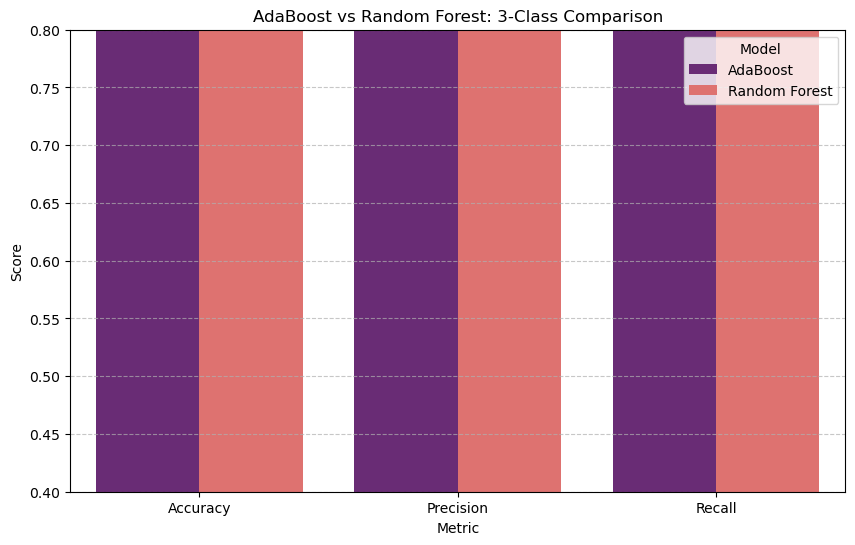

In [71]:
comparison_df = pd.DataFrame(results).set_index("Model")
melted_df = comparison_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='magma')
plt.title('AdaBoost vs Random Forest: 3-Class Comparison')
plt.ylim(0.4, 0.8) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Model is predicting 2 classes.


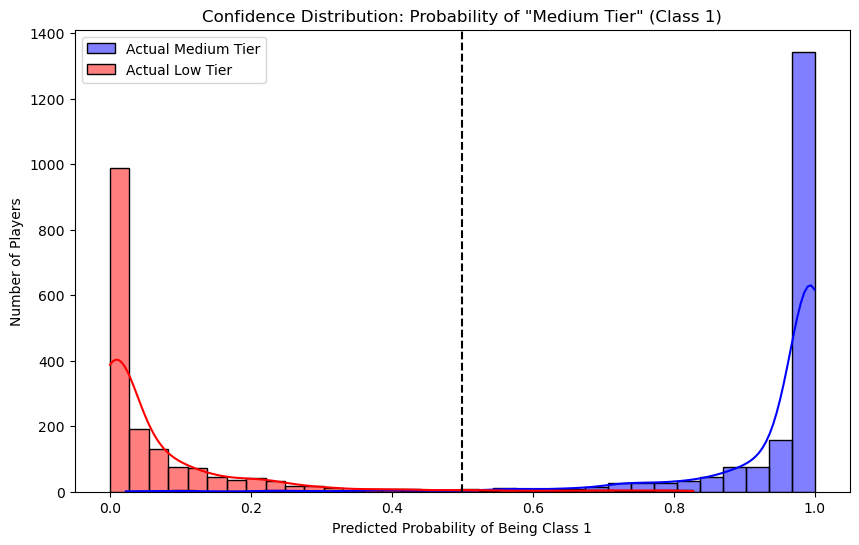

In [73]:

num_classes_predicted = y_probs.shape[1]
print(f"Model is predicting {num_classes_predicted} classes.")

plt.figure(figsize=(10, 6))

if num_classes_predicted > 2:
    # Probability of Class 2 (High Tier)
    sns.histplot(y_probs[y_test == 2, 2], color='green', label='Actual High Tier', kde=True, bins=30)
    sns.histplot(y_probs[y_test == 0, 2], color='red', label='Actual Low Tier', kde=True, bins=30)
    plt.title('Confidence Distribution: Probability of "High Tier" (Class 2)')
    plt.xlabel('Predicted Probability of Being Class 2')
else:
    # Fallback: Plot the probability of the highest available class (likely 'Medium')
    sns.histplot(y_probs[y_test == 1, 1], color='blue', label='Actual Medium Tier', kde=True, bins=30)
    sns.histplot(y_probs[y_test == 0, 1], color='red', label='Actual Low Tier', kde=True, bins=30)
    plt.title('Confidence Distribution: Probability of "Medium Tier" (Class 1)')
    plt.xlabel('Predicted Probability of Being Class 1')

plt.axvline(x=0.5, color='black', linestyle='--')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

# Feature importance and shap based on best model

Calculating SHAP values...


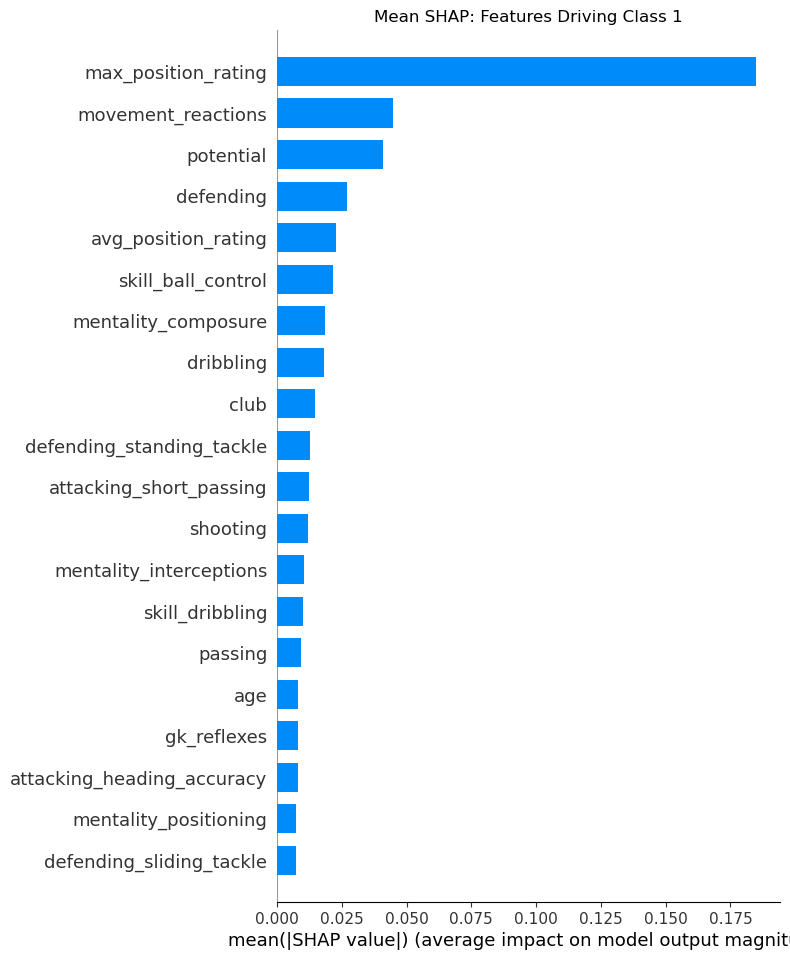

In [75]:
print("Calculating SHAP values...")
X_test_subset = X_test[best_features_list]

explainer = shap.TreeExplainer(winning_model)
shap_values = explainer.shap_values(X_test_subset)

target_class_index = y_probs.shape[1] - 1 

if isinstance(shap_values, list):
    target_shap = shap_values[target_class_index]
else:
    target_shap = shap_values[:, :, target_class_index] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="bar", show=False)
plt.title(f"Mean SHAP: Features Driving Class {target_class_index}")
plt.show()

Generating Waterfall plot for Class 1...


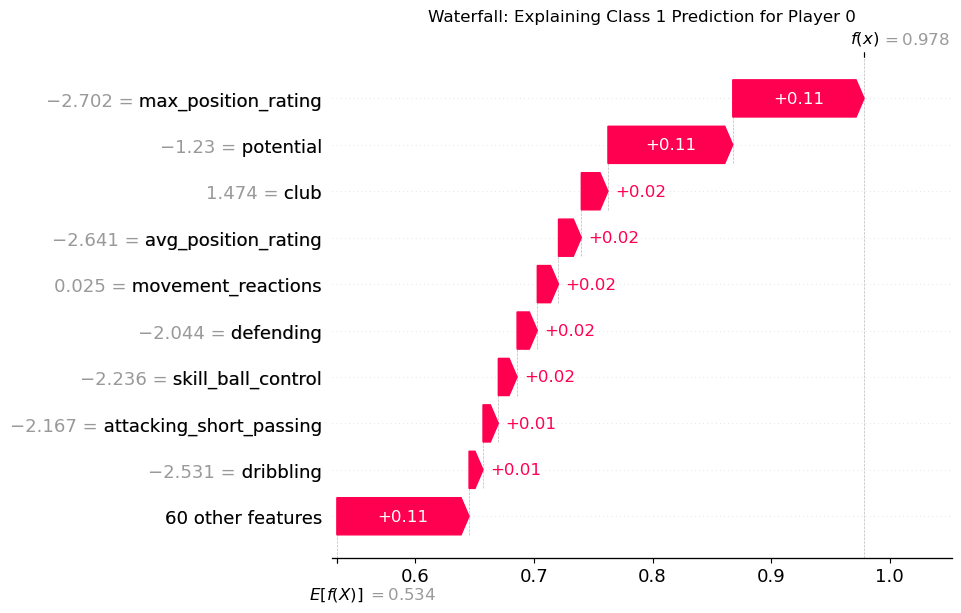

In [77]:
import shap
import matplotlib.pyplot as plt
import numpy as np

target_class_idx = y_probs.shape[1] - 1 

try:
    print(f"Generating Waterfall plot for Class {target_class_idx}...")

    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[target_class_idx]
    else:
        
        base_val = explainer.expected_value

    if isinstance(shap_values, list):
        sample_shap_values = shap_values[target_class_idx][0]
    else:
       
        sample_shap_values = shap_values[0, :, target_class_idx]

    
    exp = shap.Explanation(
        values=sample_shap_values,
        base_values=base_val,
        data=X_test_subset.iloc[0],
        feature_names=X_test_subset.columns.tolist()
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp, show=False)
    plt.title(f"Waterfall: Explaining Class {target_class_idx} Prediction for Player 0")
    plt.savefig('shap_waterfall_refined.png', bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Waterfall plot failed: {e}")
    print("Tip: Ensure 'shap_values' and 'explainer' are defined from your winning model.")

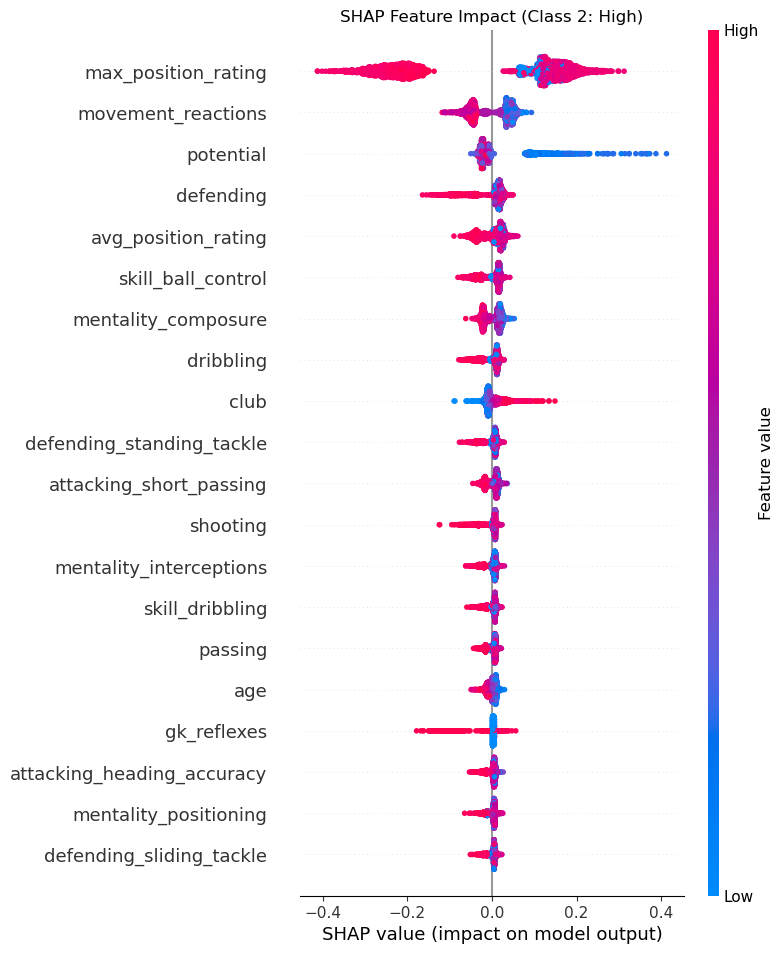

In [78]:
plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="dot", show=False) # Dot/Violin style
plt.title("SHAP Feature Impact (Class 2: High)")
plt.show()